## Example 2: Analyzing Gold (GLD) Return Distribution

### Dataset Description
SPDR Gold Shares (GLD) is an ETF that tracks the price of gold. Gold is 
considered a "safe-haven" asset that investors buy during uncertainty.
We analyze how its return distribution compares to stocks.

**Source:** Yahoo Finance  
**Period:** 2014-2024  
**Relevance:** Different asset class — tests if our findings apply beyond stocks

### Problem Setup
We will test if Gold's daily returns are normally distributed and compare
its behavior to the stocks we analyzed earlier.

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [5]:
# Step 1: Download Gold Data
gold = yf.download("GLD", start="2014-01-01", end="2024-01-01", progress=False)
gold_prices = gold['Close']
print(f"Gold (GLD): {len(gold_prices)} trading days downloaded")

Gold (GLD): 2516 trading days downloaded


In [7]:
# Step 2: Calculate Log Returns

gold_returns = np.log(gold_prices / gold_prices.shift(1)).dropna()
gold_ret = gold_returns.values.flatten()  # Flatten to 1D array
print(f"Gold: {len(gold_ret)} daily returns calculated")

Gold: 2515 daily returns calculated


In [9]:
# Calculate Statistics

print("\n=== Gold Statistics ===")
print(f"Mean (%):          {np.mean(gold_ret) * 100:.4f}")
print(f"Std Dev (%):       {np.std(gold_ret) * 100:.4f}")
print(f"Skewness:          {stats.skew(gold_ret):.4f}")
print(f"Excess Kurtosis:   {stats.kurtosis(gold_ret):.4f}")
print(f"Min (%):           {np.min(gold_ret) * 100:.4f}")
print(f"Max (%):           {np.max(gold_ret) * 100:.4f}")


=== Gold Statistics ===
Mean (%):          0.0192
Std Dev (%):       0.8881
Skewness:          -0.0739
Excess Kurtosis:   2.9246
Min (%):           -5.5190
Max (%):           4.7874


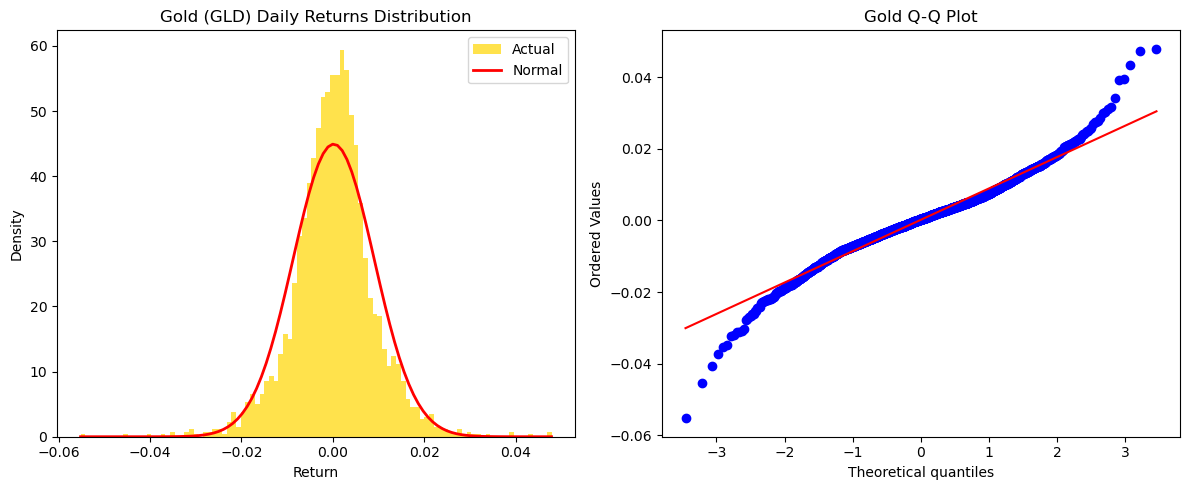

In [11]:
# Step 4: Visualize Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
axes[0].hist(gold_ret, bins=100, density=True, alpha=0.7, color='gold', label='Actual')
x = np.linspace(gold_ret.min(), gold_ret.max(), 100)
axes[0].plot(x, stats.norm.pdf(x, gold_ret.mean(), gold_ret.std()), 'r-', lw=2, label='Normal')
axes[0].set_title('Gold (GLD) Daily Returns Distribution')
axes[0].set_xlabel('Return')
axes[0].set_ylabel('Density')
axes[0].legend()

# Q-Q Plot
stats.probplot(gold_ret, dist="norm", plot=axes[1])
axes[1].set_title('Gold Q-Q Plot')

plt.tight_layout()
plt.savefig('gold_distribution.png', dpi=150)
plt.show()


In [13]:
# Step 5: Normality Tests

print("\n=== Normality Tests ===")

# Jarque-Bera Test
jb_stat, jb_pvalue = stats.jarque_bera(gold_ret)
print(f"Jarque-Bera: statistic={jb_stat:.2f}, p-value={jb_pvalue:.2e}")

# Shapiro-Wilk Test
sw_stat, sw_pvalue = stats.shapiro(gold_ret[:5000])
print(f"Shapiro-Wilk: statistic={sw_stat:.4f}, p-value={sw_pvalue:.2e}")

if jb_pvalue < 0.05:
    print("Result: REJECT normality (p < 0.05)")
else:
    print("Result: Cannot reject normality")


=== Normality Tests ===
Jarque-Bera: statistic=898.59, p-value=7.47e-196
Shapiro-Wilk: statistic=0.9706, p-value=2.58e-22
Result: REJECT normality (p < 0.05)


In [15]:
# Step 6: Tail Analysis

std = gold_ret.std()

print("\n=== Tail Analysis ===")
print(f"{'Event':<20} {'Actual':<10} {'Normal Expects':<15} {'Ratio':<10}")
print("-" * 55)

for n_std in [2, 3, 4]:
    actual = (np.abs(gold_ret) > n_std * std).sum()
    expected = len(gold_ret) * 2 * (1 - stats.norm.cdf(n_std))
    ratio = actual / expected if expected > 0 else np.inf
    print(f"Beyond {n_std} std dev     {actual:<10} {expected:<15.1f} {ratio:<10.1f}x")



=== Tail Analysis ===
Event                Actual     Normal Expects  Ratio     
-------------------------------------------------------
Beyond 2 std dev     140        114.4           1.2       x
Beyond 3 std dev     31         6.8             4.6       x
Beyond 4 std dev     9          0.2             56.5      x


In [19]:

# Interpretation

print("\n=== Interpretation ===")
print("""
Gold shows different characteristics than stocks:
- Lower volatility than stocks (smaller std dev)
- Still exhibits fat tails (kurtosis > 0)
- Non-normal distribution confirmed
- Even "safe" assets don't follow the bell curve
Key insight: Non-normality is a universal feature of financial 
returns, not limited to risky assets like stocks or crypto.
""")


=== Interpretation ===

Gold shows different characteristics than stocks:
- Lower volatility than stocks (smaller std dev)
- Still exhibits fat tails (kurtosis > 0)
- Non-normal distribution confirmed
- Even "safe" assets don't follow the bell curve
Key insight: Non-normality is a universal feature of financial 
returns, not limited to risky assets like stocks or crypto.

